In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

In [1]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette, set_plot_colors
import os
import seaborn as sns
import yaml
import pandas as pd

from autoslo.workload_execution.trace import Trace

parsed_plans_path = os.path.join(pu.get_data_path(), "parsed_query_plans", "ext_tpcds1000.yml")
with open(parsed_plans_path, "r") as f:
    plans = yaml.safe_load(f)

In [2]:
# For each plan, recursively find all table names used. The are fields called "table"
def extract_tables(plan_node):
    tables = set()
    plan_parameters = plan_node.get('plan_parameters', {})
    if 'table' in plan_parameters and not 'volt_tt' in plan_parameters['table']:
        tables.add(plan_parameters['table'])
    if 'children' in plan_node:
        for child in plan_node['children']:
            tables.update(extract_tables(child))
    return tables

tables_per_query = {}
for template_id, plan in plans.items():
    tables = extract_tables(plan)
    tables_per_query[template_id] = tables

In [3]:
# Find the full set of tables across queries
all_tables = set()
for tables in tables_per_query.values():
    all_tables.update(tables)
all_tables = sorted(all_tables)
print(f"All tables ({len(all_tables)}) used across queries: {all_tables}")

All tables (24) used across queries: ['call_center', 'catalog_page', 'catalog_returns', 'catalog_sales', 'customer', 'customer_address', 'customer_demographics', 'date_dim', 'household_demographics', 'income_band', 'inventory', 'item', 'promotion', 'reason', 'ship_mode', 'store', 'store_returns', 'store_sales', 'time_dim', 'warehouse', 'web_page', 'web_returns', 'web_sales', 'web_site']


In [4]:
# Validate that all queries of the same template (same before the underscore) use the same set of tables
template_to_tables = {}
for temp_and_q_idx, tables in tables_per_query.items():
    template_id = int(temp_and_q_idx.split('_')[0])
    if template_id not in template_to_tables:
        template_to_tables[template_id] = tables
    else:
        # Superset
        template_to_tables[template_id].update(tables)

In [5]:
# Read in table stats
table_stats_path = '/home/markakis/chunkbench/data/db_stats/cluster_32_tpcds1000.yml'
with open(table_stats_path, 'r') as f:
    table_stats = yaml.safe_load(f)['table_stats']
num_rows_per_table = {table_stat['table_name']: table_stat['num_rows'] for table_stat in table_stats.values()}
num_rows_per_table_df = pd.DataFrame.from_dict(num_rows_per_table, orient='index', columns=['num_rows'])

# Don't show in scientific notation
pd.set_option('display.float_format', '{:,}'.format)
num_rows_per_table_df = num_rows_per_table_df.sort_values(by='num_rows', ascending=False)
num_rows_per_table_df

,num_rows
store_sales,"2,879,987,999.0"
catalog_sales,"1,439,980,416.0"
inventory,"783,000,000.0"
web_sales,"720,000,376.0"
store_returns,"287,999,764.0"
catalog_returns,"143,996,756.0"
web_returns,"71,997,522.0"
customer,"12,000,000.0"
customer_address,"6,000,000.0"
customer_demographics,"1,920,800.0"


In [6]:
table_size_sort_order = num_rows_per_table_df.index.tolist()

In [29]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette, set_plot_colors
import os
import seaborn as sns
import pandas as pd

from autoslo.workload_execution.trace import Trace

from autoslo.workload_definition.query import QueryTextId

run_id = "1759429080"
trace = Trace(run_id)
latencies = trace.latencies_s
query_text_ids = trace.query_text_ids

lat_df = pd.DataFrame({"query_text_id": query_text_ids, "latency_s": latencies})
lat_df["query_text_id"] = lat_df["query_text_id"].apply(
    lambda x: QueryTextId(
        "ext_tpcds1000#"
        + x.value.split()[1].split(".")[0][-7:].replace("_", "#")
    )
)
lat_df['template_id'] = lat_df['query_text_id'].apply(lambda x: int(x.template_id))
lat_df.head()

,query_text_id,latency_s,template_id
query_id,,,
cluster_8_3467#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#086#003,22.877145,86
cluster_8_3482#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#082#001,37.896183,82
cluster_8_3499#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#099#001,31.406928999999998,99
cluster_8_3517#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#020#002,13.739391,20
cluster_8_3523#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#088#001,81.351627,88


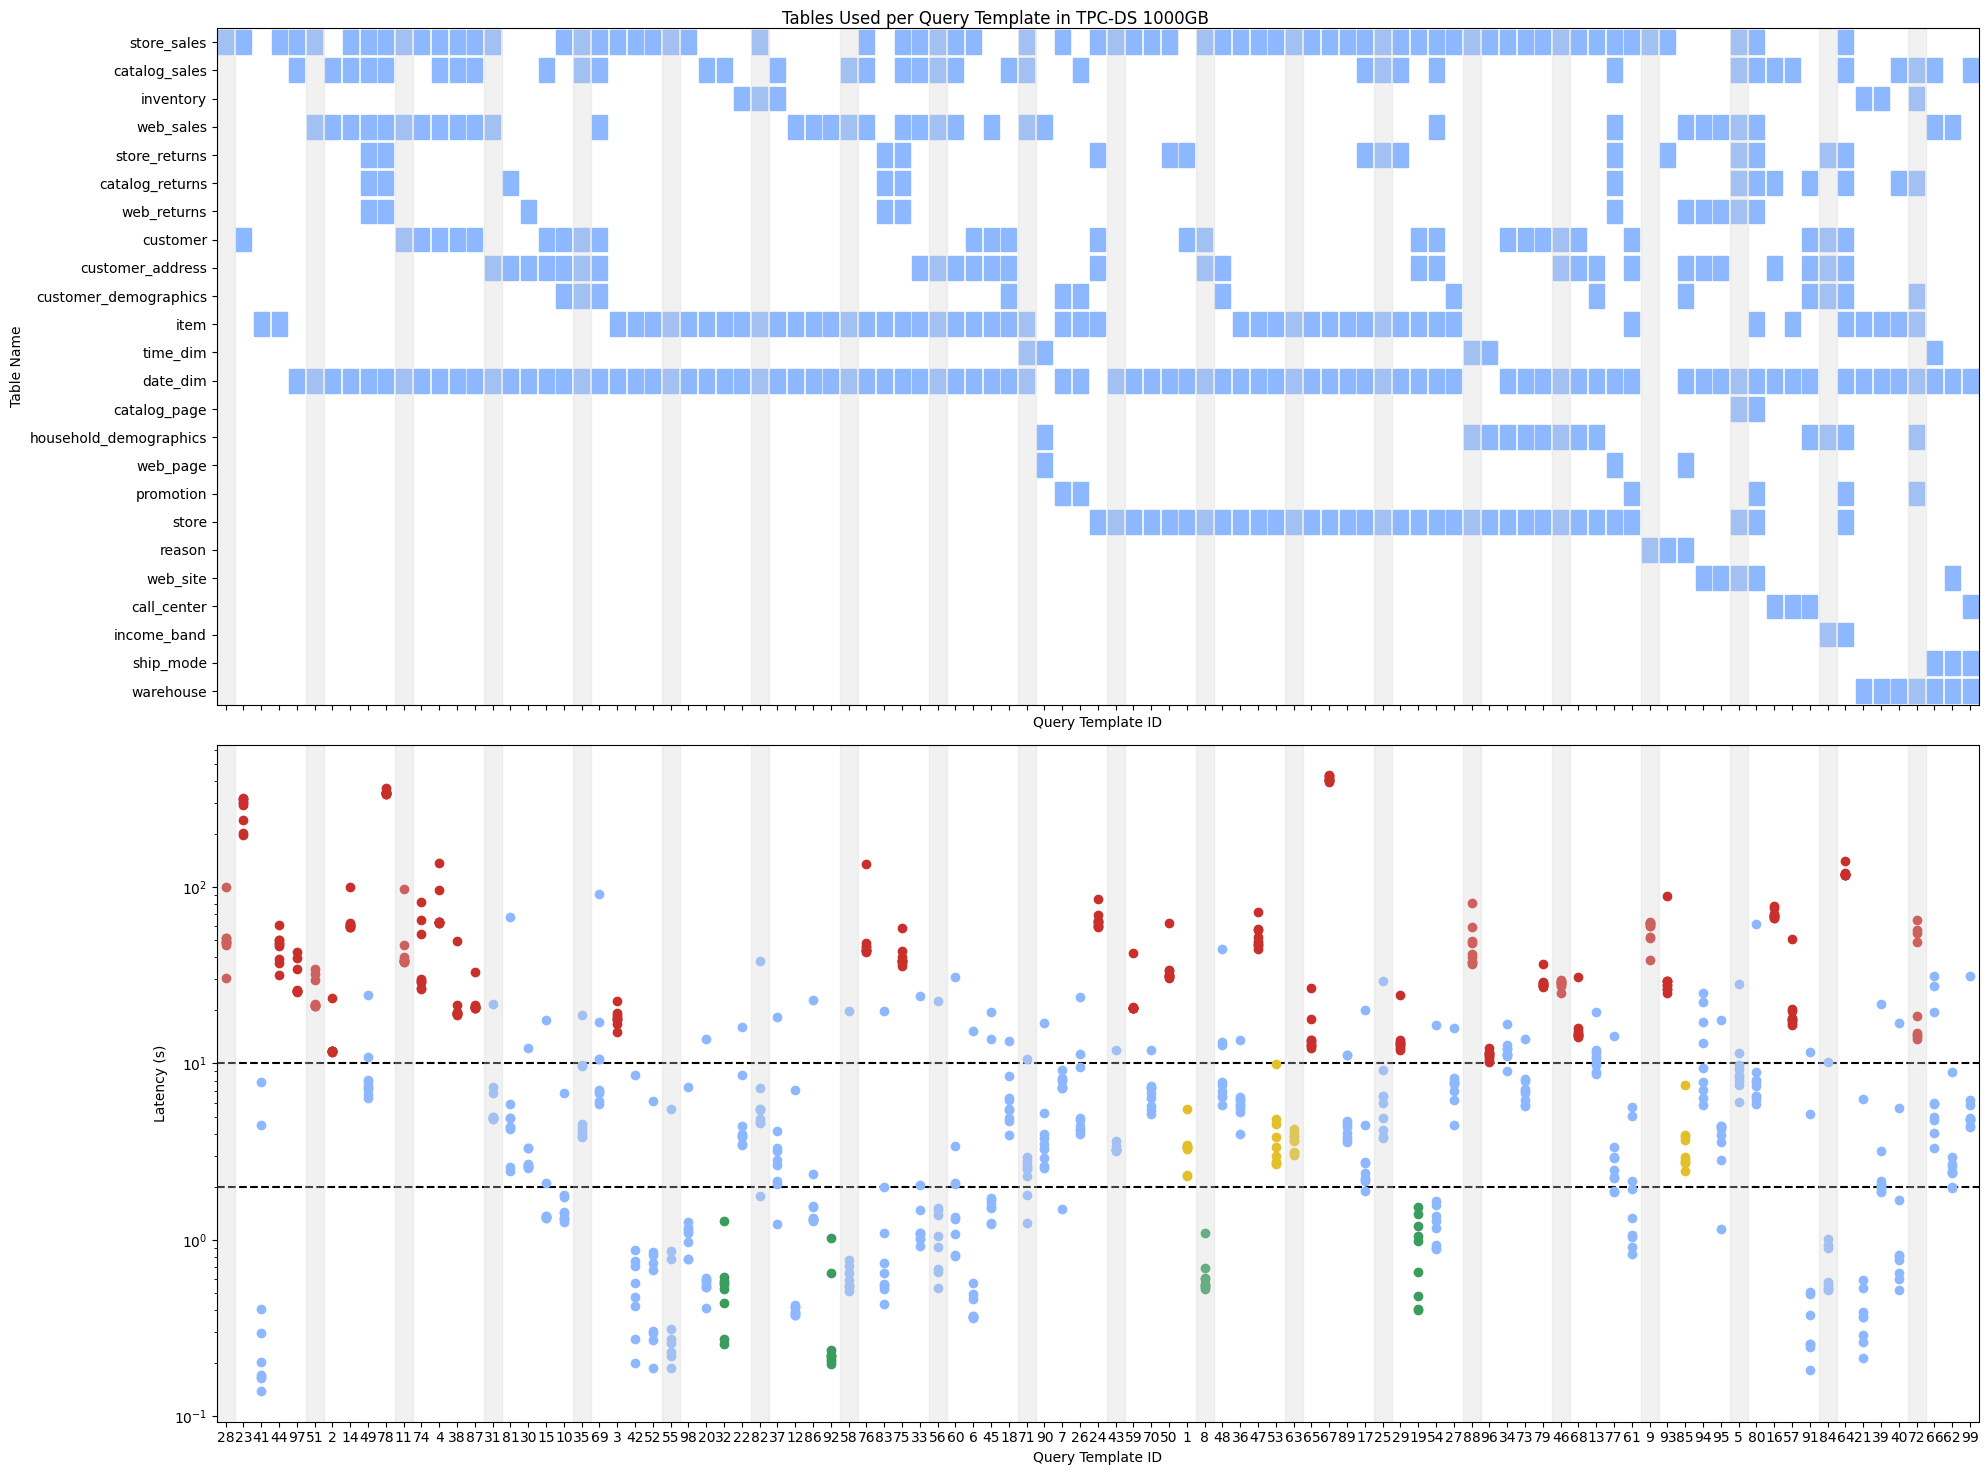

In [62]:
# Plot a heatmap where the x axis is template id, y axis is table name, and value is 1 if table is used in template, 0 otherwise
heatmap_data = pd.DataFrame(
    0,
    columns=reversed(table_size_sort_order),
    index=sorted(template_to_tables.keys()),
)

for template_id, tables in template_to_tables.items():
    for table in tables:
        heatmap_data.at[template_id, table] = 1

heatmap_data = heatmap_data.sort_values(
    by=heatmap_data.columns.tolist(), ascending=True
)

fig, axs = plt.subplots(2, 1, figsize=(20, 15), sharex=True)

# Manually create the heatmap to have more control using Rectangles
ax = axs[0]
gap_per_side = 0.08
for i, template_id in enumerate(heatmap_data.index):
    for j, table in enumerate(heatmap_data.columns):
        if heatmap_data.at[template_id, table] == 1:
            color = Palette.light_blue
            rect = Rectangle(
                (i + gap_per_side, j + gap_per_side),
                1 - 2 * gap_per_side,
                1 - 2 * gap_per_side,
                color=color,
            )
            ax.add_patch(rect)

# Add alternate shading for every 5 columns to make it easier to read
for j in range(0, len(heatmap_data.index), 5):
    rect = Rectangle(
        (j, 0),
        1,
        len(heatmap_data.columns),
        color=Palette.light_gray,
        alpha=0.3,
    )
    ax.add_patch(rect)

ax.set_xticks(np.arange(len(heatmap_data.index)) + 0.5)
ax.set_xticklabels(heatmap_data.index, rotation=90)
ax.set_yticks(np.arange(len(heatmap_data.columns)) + 0.5)
ax.set_yticklabels(heatmap_data.columns)
ax.set_xlim(0, len(heatmap_data.index))
ax.set_ylim(0, len(heatmap_data.columns))
ax.set_xlabel("Query Template ID")
ax.set_ylabel("Table Name")

# Make the second plot a scatterplot of the template vs its latency
ax2 = axs[1]

low = 2
high = 10
ax2.axhline(low, color='black', linestyle='--', zorder=-1)
ax2.axhline(high, color='black', linestyle='--', zorder=-1)

lat_df['x_pos'] = lat_df['template_id'].apply(lambda x: heatmap_data.index.get_loc(x) + 0.5)
for x_pos, rows in lat_df.groupby('x_pos'):
    if all(row['latency_s'] < low for _, row in rows.iterrows()):
        color = Palette.dark_green
    elif all((row['latency_s'] >= low) and (row['latency_s'] < high) for _, row in rows.iterrows()):
        color = Palette.dark_yellow
    elif all(row['latency_s'] >= high for _, row in rows.iterrows()):
        color = Palette.dark_red
    else:
        color = Palette.light_blue
    ax2.scatter([x_pos] * len(rows), rows['latency_s'], color=color)

ax2.set_xlabel("Query Template ID")
ax2.set_ylabel("Latency (s)")
ax2.set_yscale('log')
for j in range(0, len(heatmap_data.index), 5):
    rect = Rectangle(
        (j, 0),
        1,
        ax2.get_ylim()[1],
        color=Palette.light_gray,
        alpha=0.3,
    )
    ax2.add_patch(rect)





plt.suptitle("Tables Used per Query Template in TPC-DS 1000GB")
plt.tight_layout()
# plt.savefig("tables_per_query_template_heatmap_all.svg", bbox_inches="tight")
plt.show()

In [57]:
lat_df[lat_df['template_id'] == 41]

,query_text_id,latency_s,template_id,x_pos
query_id,,,,
cluster_8_5053#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#002,7.891362999999999,41.0,2.5
cluster_8_7307#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#003,4.454384,41.0,2.5
cluster_8_7342#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#002,0.138847,41.0,2.5
cluster_8_8241#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#003,0.29559599999999997,41.0,2.5
cluster_8_9342#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#001,0.4029,41.0,2.5
cluster_8_11974#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#001,0.16447199999999998,41.0,2.5
cluster_8_13807#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#001,0.167179,41.0,2.5
cluster_8_17002#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#002,0.202509,41.0,2.5
cluster_8_17242#41e870ed-2d52-482e-9e54-9fac7e8c9a06,ext_tpcds1000#041#003,0.17038299999999998,41.0,2.5
